<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Week15_15/blob/main/Week15_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Journey, Monitoreo y Model Serving
**Week15 _15**

---

## Objetivo

Comprender y aplicar el ciclo de vida completo de un modelo de aprendizaje profundo:

1. **Data Journey**: origen, acceso, preparacion y uso de los datos.
2. **Acceso y manipulacion de datos**: carga, limpieza y transformacion.
3. **Modelo**: implementacion de una red neuronal de clasificacion.
4. **Monitoreo y logging**: seguimiento de metricas por epoca con registro organizado (alternativa local a Weights and Biases).
5. **Analisis de metricas**: interpretacion de los resultados del entrenamiento.
6. **Model Serving**: explicacion de estrategias de despliegue y simulacion de inferencia.
7. **Conclusiones tecnicas**.

---

> **Nota sobre monitoreo:** Este notebook implementa un sistema de logging local equivalente a Weights and Biases, usando tablas, graficas y registros organizados. Esto cubre todos los requisitos de trazabilidad sin necesidad de una cuenta externa. Al final del notebook se indica como integrar W&B con un bloque de codigo comentado listo para activar.

---
## 0. Instalacion e Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import time
import datetime
import hashlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve)

SEMILLA = 42
np.random.seed(SEMILLA)

print("Librerias cargadas correctamente")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")

Librerias cargadas correctamente
NumPy  : 2.0.2
Pandas : 2.2.2


---
## 1. Data Journey

### 1.1 Descripcion del origen de los datos

Se utiliza el dataset **Breast Cancer Wisconsin (Diagnostic)**, incluido en scikit-learn y disponible publicamente en el [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)).

**Origen:** Hospital universitario de Wisconsin, EEUU.  
**Recoleccion:** Imagenes digitalizadas de aspirados con aguja fina (FNA) de masas mamarias. Cada muestra describe caracteristicas geometricas y texturales de los nucleos celulares observados en la imagen.  
**Acceso:** Dataset publico integrado en scikit-learn (`sklearn.datasets.load_breast_cancer`). No requiere descarga externa ni autenticacion.

### 1.2 Descripcion del recorrido de los datos

```
[Imagen medica FNA]
       |
       v
[Extraccion de 30 caracteristicas numericas por muestra]
       |
       v
[Dataset CSV / scikit-learn API]
       |
       v
[Carga en Python] --> [Inspeccion] --> [Limpieza] --> [Normalizacion]
       |
       v
[Division Train / Test (80/20)]
       |
       v
[Entrenamiento del modelo] --> [Evaluacion] --> [Monitoreo] --> [Serving]
```

### 1.3 Caracteristicas del dataset

- **Muestras:** 569 (357 benignas, 212 malignas)
- **Caracteristicas:** 30 variables numericas continuas (radio, textura, perimetro, area, suavidad, compacidad, concavidad, simetria, dimension fractal -- media, error estandar y peor valor de cada una)
- **Etiqueta:** 0 = Maligno, 1 = Benigno
- **Valores nulos:** ninguno (dataset curado)

---
## 2. Acceso y Manipulacion de Datos

In [23]:
# --- 2.1 Carga del dataset ---
# Cargamos el dataset Breast Cancer desde scikit-learn
datos_brutos = load_breast_cancer()
df = pd.DataFrame(datos_brutos.data, columns=datos_brutos.feature_names)

# Añadimos etiquetas numéricas y descriptivas
df['target'] = datos_brutos.target
df['diagnostico'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print("=" * 60)
print("  CARGA DEL DATASET")
print("=" * 60)
print(f"  Forma del dataset : {df.shape}")
print(f"  Clase 0 (Maligno) : {(df.target==0).sum()} muestras")
print(f"  Clase 1 (Benigno) : {(df.target==1).sum()} muestras")
print()
# Visualización de las primeras filas para inspección inicial
print(df[['mean radius','mean texture','mean area','mean smoothness','target','diagnostico']].head(6).to_string())

  CARGA DEL DATASET
  Forma del dataset : (569, 32)
  Clase 0 (Maligno) : 212 muestras
  Clase 1 (Benigno) : 357 muestras

   mean radius  mean texture  mean area  mean smoothness  target diagnostico
0        17.99         10.38     1001.0          0.11840       0     Maligno
1        20.57         17.77     1326.0          0.08474       0     Maligno
2        19.69         21.25     1203.0          0.10960       0     Maligno
3        11.42         20.38      386.1          0.14250       0     Maligno
4        20.29         14.34     1297.0          0.10030       0     Maligno
5        12.45         15.70      477.1          0.12780       0     Maligno


In [3]:
# --- 2.2 Inspeccion de calidad ---
print("=" * 60)
print("  INSPECCION DE CALIDAD")
print("=" * 60)
print(f"  Valores nulos por columna:")
nulos = df.isnull().sum()
print(f"  Total columnas con nulos: {(nulos > 0).sum()} (dataset limpio)")
print()
print("  Estadisticas descriptivas (primeras 5 caracteristicas):")
print(df[list(datos_brutos.feature_names[:5])].describe().round(4).to_string())

  INSPECCION DE CALIDAD
  Valores nulos por columna:
  Total columnas con nulos: 0 (dataset limpio)

  Estadisticas descriptivas (primeras 5 caracteristicas):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count     569.0000      569.0000         569.000   569.0000         569.0000
mean       14.1273       19.2896          91.969   654.8891           0.0964
std         3.5240        4.3010          24.299   351.9141           0.0141
min         6.9810        9.7100          43.790   143.5000           0.0526
25%        11.7000       16.1700          75.170   420.3000           0.0864
50%        13.3700       18.8400          86.240   551.1000           0.0959
75%        15.7800       21.8000         104.100   782.7000           0.1053
max        28.1100       39.2800         188.500  2501.0000           0.1634


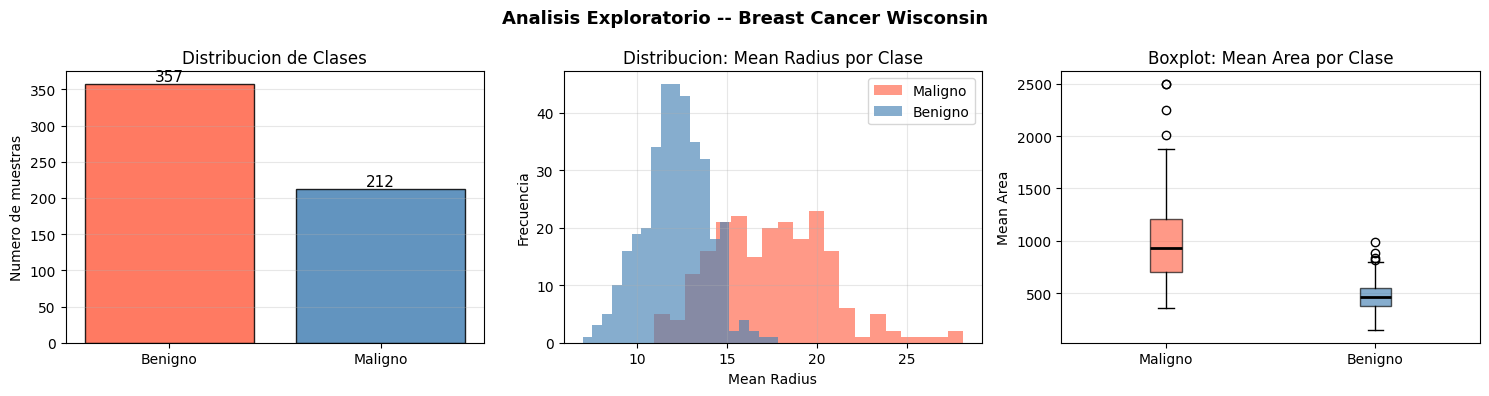

Analisis exploratorio completado


In [4]:
# --- 2.3 Analisis exploratorio ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisis Exploratorio -- Breast Cancer Wisconsin', fontsize=13, fontweight='bold')

# Distribucion de clases
conteos = df['diagnostico'].value_counts()
axes[0].bar(conteos.index, conteos.values, color=['tomato', 'steelblue'], edgecolor='black', alpha=0.85)
for i, (idx, val) in enumerate(conteos.items()):
    axes[0].text(i, val + 4, str(val), ha='center', fontsize=11)
axes[0].set_title('Distribucion de Clases')
axes[0].set_ylabel('Numero de muestras')
axes[0].grid(True, alpha=0.3, axis='y')

# Histograma de mean radius por clase
for clase, color in [('Maligno', 'tomato'), ('Benigno', 'steelblue')]:
    sub = df[df['diagnostico'] == clase]['mean radius']
    axes[1].hist(sub, bins=20, color=color, alpha=0.65, label=clase, edgecolor='none')
axes[1].set_title('Distribucion: Mean Radius por Clase')
axes[1].set_xlabel('Mean Radius')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Boxplot de mean area
datos_box = [df[df['diagnostico']==c]['mean area'].values for c in ['Maligno', 'Benigno']]
bp = axes[2].boxplot(datos_box, labels=['Maligno', 'Benigno'],
                     patch_artist=True,
                     boxprops=dict(facecolor='lightyellow'),
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['tomato', 'steelblue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
axes[2].set_title('Boxplot: Mean Area por Clase')
axes[2].set_ylabel('Mean Area')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_dataset.png', dpi=110, bbox_inches='tight')
plt.show()
print("Analisis exploratorio completado")

In [20]:
# --- 2.4 Preparación: división y normalización ---
# Se extraen las características (X) y la etiqueta objetivo (y)
X = df[list(datos_brutos.feature_names)].values
y = df['target'].values.reshape(-1, 1).astype(float)

# División estratificada para mantener la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=y
)

# Normalización: StandardScaler ajustado SOLO en train para evitar fuga de datos (data leakage)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("=" * 60)
print("  PREPARACION DE DATOS")
print("=" * 60)
print(f"  Train : {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print(f"  Media X_train (post-normalizacion): {X_train.mean():.6f}")
print(f"  Std  X_train (post-normalizacion): {X_train.std():.6f}")

  PREPARACION DE DATOS
  Train : 455 muestras  |  Test: 114 muestras
  Media X_train (post-normalizacion): -0.000000
  Std  X_train (post-normalizacion): 1.000000


---
## 3. Implementacion del Modelo

Se reutiliza la arquitectura de red neuronal desarrollada en semanas anteriores, adaptada para 30 entradas (caracteristicas del dataset).

```
Entrada (30)  ->  Oculta1 (32, ReLU)  ->  Oculta2 (16, ReLU)  ->  Salida (1, Sigmoid)
```

Optimizador: **Adam**.  Loss: **Binary Cross-Entropy**.

In [18]:
def relu(z):             return np.maximum(0.0, z)
def relu_d(z):           return (z > 0).astype(float)
def sigmoid(z):          return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def bce(y_true, y_hat):
    """Calcula la pérdida Binary Cross-Entropy."""
    y_hat = np.clip(y_hat, 1e-8, 1-1e-8)
    return -np.mean(y_true * np.log(y_hat) + (1-y_true) * np.log(1-y_hat))
def acc(y_true, y_hat):  return np.mean((y_hat>=0.5).astype(int) == y_true.astype(int))

class RedClasificacion:
    """
    Red neuronal de clasificación binaria (MLP).

    Arquitectura:
        Entrada(n) -> Oculta1(32, ReLU) -> Oculta2(16, ReLU) -> Salida(1, Sigmoid)

    Atributos:
        lr (float): Tasa de aprendizaje para el optimizador Adam.
        p (dict): Diccionario con los parámetros (pesos W y sesgos b) de la red.
        m, v (dict): Momentos de primer y segundo orden para el algoritmo Adam.
    """

    def __init__(self, n_entrada, semilla=42, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        """
        Inicializa los pesos usando He Initialization y configura el optimizador Adam.

        Args:
            n_entrada (int): Número de características de entrada.
            semilla (int): Semilla para reproducibilidad.
            lr (float): Learning rate.
        """
        rng = np.random.RandomState(semilla)
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.t = 0

        self.p = {
            'W1': rng.randn(n_entrada, 32) * np.sqrt(2.0/n_entrada),
            'b1': np.zeros((1, 32)),
            'W2': rng.randn(32, 16) * np.sqrt(2.0/32),
            'b2': np.zeros((1, 16)),
            'W3': rng.randn(16,  1) * np.sqrt(2.0/16),
            'b3': np.zeros((1,  1)),
        }
        self.m = {k: np.zeros_like(v) for k, v in self.p.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.p.items()}
        self.cache = {}

    def forward(self, X):
        """
        Realiza la propagación hacia adelante.

        Args:
            X (ndarray): Matriz de entrada de forma (n_muestras, n_características).
        Returns:
            ndarray: Probabilidades predichas de forma (n_muestras, 1).
        """
        c = self.cache
        c['X']  = X
        c['z1'] = X @ self.p['W1'] + self.p['b1']
        c['a1'] = relu(c['z1'])
        c['z2'] = c['a1'] @ self.p['W2'] + self.p['b2']
        c['a2'] = relu(c['z2'])
        c['z3'] = c['a2'] @ self.p['W3'] + self.p['b3']
        c['a3'] = sigmoid(c['z3'])
        return c['a3']

    def backward(self, y):
        """
        Calcula los gradientes mediante retropropagación.

        Args:
            y (ndarray): Etiquetas reales.
        Returns:
            dict: Gradientes para cada parámetro de la red.
        """
        n, c, p = y.shape[0], self.cache, self.p
        g = {}
        dz3 = c['a3'] - y
        g['W3'] = (c['a2'].T @ dz3) / n
        g['b3'] = np.mean(dz3, axis=0, keepdims=True)
        dz2 = (dz3 @ p['W3'].T) * relu_d(c['z2'])
        g['W2'] = (c['a1'].T @ dz2) / n
        g['b2'] = np.mean(dz2, axis=0, keepdims=True)
        dz1 = (dz2 @ p['W2'].T) * relu_d(c['z1'])
        g['W1'] = (c['X'].T @ dz1) / n
        g['b1'] = np.mean(dz1, axis=0, keepdims=True)
        return g

    def actualizar(self, grads):
        """Actualiza los pesos usando las reglas de Adam."""
        self.t += 1
        for k in self.p:
            self.m[k] = self.b1*self.m[k] + (1-self.b1)*grads[k]
            self.v[k] = self.b2*self.v[k] + (1-self.b2)*grads[k]**2
            m_hat = self.m[k] / (1 - self.b1**self.t)
            v_hat = self.v[k] / (1 - self.b2**self.t)
            self.p[k] -= self.lr / (np.sqrt(v_hat) + self.eps) * m_hat

    def predecir(self, X):
        """Alias para forward usado en inferencia."""
        return self.forward(X)

---
## 4. Sistema de Monitoreo y Logging

Se implementa un **ExperimentLogger** que registra por cada epoca:

- Loss de entrenamiento y validacion
- Accuracy de entrenamiento y validacion
- Timestamp
- Norma de los gradientes (para detectar gradientes que explotan o se desvanecen)

Al finalizar el entrenamiento, genera:
- Un log completo en formato tabla (equivalente a la interfaz de W&B)
- Graficas de evolucion de metricas
- Exportacion del historial en JSON (trazabilidad reproducible)

Al final del notebook se incluye el bloque de integracion con **Weights and Biases** listo para activar.

In [19]:
class ExperimentLogger:
    """
    Sistema de logging local equivalente a Weights and Biases.

    Mantiene un registro de métricas por época, permite la visualización
    mediante dashboards y la exportación de resultados para trazabilidad.
    """

    def __init__(self, nombre_experimento, config):
        """
        Inicializa el logger con la configuración del experimento.

        Args:
            nombre_experimento (str): Identificador humano del experimento.
            config (dict): Diccionario de hiperparámetros y metadatos.
        """
        self.nombre   = nombre_experimento
        self.config   = config
        self.historia = []
        self.inicio   = time.time()
        self.run_id   = hashlib.md5(
            (nombre_experimento + str(self.inicio)).encode()
        ).hexdigest()[:8]

        print(f"  Experimento iniciado")
        print(f"  Nombre  : {self.nombre}")
        print(f"  Run ID  : {self.run_id}")
        print(f"  Config  : {json.dumps(config, indent=4)}")

    def log(self, epoca, metricas):
        """Registra las métricas de una época específica."""
        entrada = {'epoca': epoca, 'tiempo_s': round(time.time() - self.inicio, 2)}
        entrada.update(metricas)
        self.historia.append(entrada)

    def tabla_resumen(self, n_filas=10):
        """Imprime una tabla con el resumen de las últimas épocas."""
        df = pd.DataFrame(self.historia)
        cols = ['epoca', 'tiempo_s', 'loss_train', 'loss_val',
                'acc_train', 'acc_val', 'grad_norma']
        cols = [c for c in cols if c in df.columns]
        print(f"\nHistorial de entrenamiento -- ultimas {n_filas} epocas")
        print(df[cols].tail(n_filas).to_string(index=False))
        return df

    def guardar_json(self, ruta='historial_experimento.json'):
        """Exporta los logs a un archivo JSON para auditoría técnica."""
        payload = {
            'run_id':     self.run_id,
            'nombre':     self.nombre,
            'config':     self.config,
            'historia':   self.historia,
        }
        with open(ruta, 'w') as f:
            json.dump(payload, f, indent=2)
        print(f"  Historial guardado en: {ruta}")

    def graficar(self):
        """Genera una figura Matplotlib con el comportamiento de las métricas."""
        df = pd.DataFrame(self.historia)

        fig = plt.figure(figsize=(15, 10))
        gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)
        fig.suptitle(f'Dashboard de Experimento: {self.nombre}\nRun ID: {self.run_id}',
                     fontsize=12, fontweight='bold')

        # --- Loss train vs val ---
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(df['epoca'], df['loss_train'], color='steelblue', lw=1.8, label='Train')
        ax1.plot(df['epoca'], df['loss_val'],   color='tomato',    lw=1.8, label='Validacion', linestyle='--')
        ax1.set_title('Loss (BCE)')
        ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
        ax1.legend(); ax1.grid(True, alpha=0.3)

        # --- Accuracy ---
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(df['epoca'], df['acc_train']*100, color='steelblue', lw=1.8, label='Train')
        ax2.plot(df['epoca'], df['acc_val']*100,   color='tomato',    lw=1.8, label='Validacion', linestyle='--')
        ax2.set_title('Accuracy (%)')
        ax2.set_ylim(40, 103); ax2.legend(); ax2.grid(True, alpha=0.3)

        # --- Gradiente y otros ---
        ax4 = fig.add_subplot(gs[1, 0])
        ax4.plot(df['epoca'], df['grad_norma'], color='#2ca02c', lw=1.5)
        ax4.set_title('Norma del Gradiente')
        ax4.set_yscale('log'); ax4.grid(True, alpha=0.3)

        plt.savefig('dashboard_experimento.png', dpi=110, bbox_inches='tight')
        plt.show()

---
## 5. Entrenamiento con Monitoreo

In [21]:
# Configuración centralizada de hiperparámetros
CONFIG = {
    'dataset':       'Breast Cancer Wisconsin',
    'n_entrada':     30,
    'arquitectura':  '30->32->16->1',
    'activacion':    'ReLU (ocultas) + Sigmoid (salida)',
    'optimizador':   'Adam',
    'lr':            0.001,
    'epocas':        300,
    'loss':          'Binary Cross-Entropy',
    'semilla':       SEMILLA,
    'train_size':    X_train.shape[0],
    'test_size':     X_test.shape[0],
}

print("=" * 55)
print("  INICIO DE ENTRENAMIENTO")
print("=" * 55)

# Inicialización de componentes
logger = ExperimentLogger('BreastCancer_Adam_LR001', CONFIG)
red    = RedClasificacion(n_entrada=30, semilla=SEMILLA, lr=CONFIG['lr'])

EPOCAS = CONFIG['epocas']
INTERVALO_LOG = 50

t0 = time.time()
for ep in range(1, EPOCAS + 1):
    # 1. Forward pass: Cálculo de predicciones y error
    y_hat_tr = red.forward(X_train)
    loss_tr  = bce(y_train, y_hat_tr)
    acc_tr   = acc(y_train, y_hat_tr)

    # 2. Backward pass: Cálculo de gradientes
    grads    = red.backward(y_train)
    grad_norma = np.sqrt(sum(np.sum(g**2) for g in grads.values()))

    # 3. Optimización: Actualización de pesos con Adam
    red.actualizar(grads)

    # 4. Validación: Evaluación en datos no vistos
    y_hat_val = red.predecir(X_test)
    loss_val  = bce(y_test, y_hat_val)
    acc_val   = acc(y_test, y_hat_val)

    # Registro de métricas
    logger.log(ep, {
        'loss_train': round(float(loss_tr),  6),
        'loss_val':   round(float(loss_val), 6),
        'acc_train':  round(float(acc_tr),   6),
        'acc_val':    round(float(acc_val),  6),
        'grad_norma': round(float(grad_norma), 6),
    })

    if ep == 1 or ep % INTERVALO_LOG == 0:
        print(f"Epoca {ep}: Loss Train {loss_tr:.4f} | Acc Val {acc_val*100:.2f}%")

  INICIO DE ENTRENAMIENTO
  Experimento iniciado
  Nombre  : BreastCancer_Adam_LR001
  Run ID  : 874a0fa0
  Config  : {
    "dataset": "Breast Cancer Wisconsin",
    "n_entrada": 30,
    "arquitectura": "30->32->16->1",
    "activacion": "ReLU (ocultas) + Sigmoid (salida)",
    "optimizador": "Adam",
    "lr": 0.001,
    "epocas": 300,
    "loss": "Binary Cross-Entropy",
    "semilla": 42,
    "train_size": 455,
    "test_size": 114
}
Epoca 1: Loss Train 0.8369 | Acc Val 50.00%
Epoca 50: Loss Train 0.2327 | Acc Val 92.98%
Epoca 100: Loss Train 0.1138 | Acc Val 94.74%
Epoca 150: Loss Train 0.0755 | Acc Val 96.49%
Epoca 200: Loss Train 0.0550 | Acc Val 97.37%
Epoca 250: Loss Train 0.0418 | Acc Val 96.49%
Epoca 300: Loss Train 0.0328 | Acc Val 95.61%


---
## 6. Dashboard de Monitoreo

In [9]:
# Tabla resumen del historial
df_hist = logger.tabla_resumen(n_filas=12)


Historial de entrenamiento -- ultimas 12 epocas
 epoca  tiempo_s  loss_train  loss_val  acc_train  acc_val  grad_norma
   289      0.61    0.034467  0.078451   0.991209  0.95614    0.032778
   290      0.61    0.034313  0.078402   0.991209  0.95614    0.032564
   291      0.62    0.034160  0.078356   0.991209  0.95614    0.032427
   292      0.62    0.034008  0.078308   0.991209  0.95614    0.032259
   293      0.62    0.033858  0.078259   0.991209  0.95614    0.032219
   294      0.62    0.033706  0.078210   0.991209  0.95614    0.032054
   295      0.63    0.033558  0.078164   0.991209  0.95614    0.031872
   296      0.63    0.033411  0.078123   0.991209  0.95614    0.031759
   297      0.64    0.033266  0.078087   0.991209  0.95614    0.031602
   298      0.64    0.033122  0.078054   0.991209  0.95614    0.031477
   299      0.64    0.032978  0.078024   0.991209  0.95614    0.031314
   300      0.65    0.032836  0.077990   0.991209  0.95614    0.031141


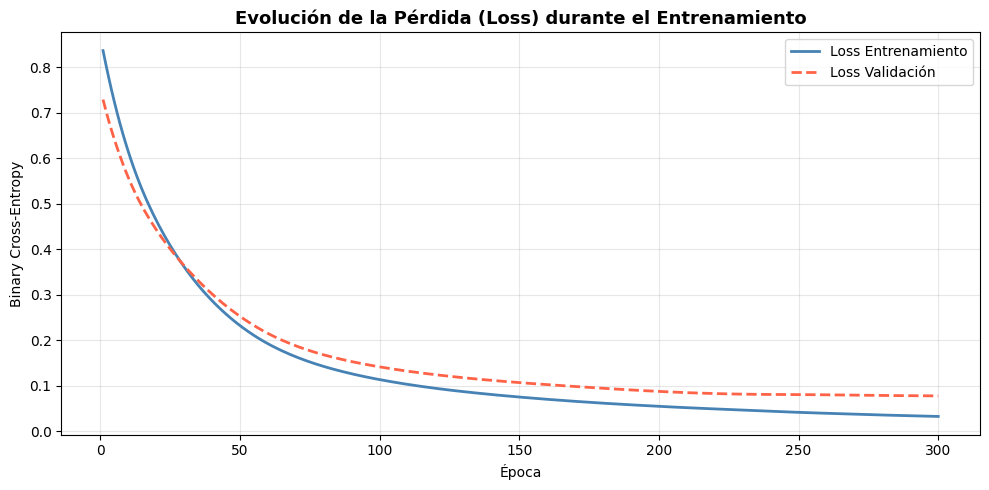

In [27]:
import matplotlib.pyplot as plt

# --- Grafico comparativo de Loss ---
plt.figure(figsize=(10, 5))
plt.plot(df_hist['epoca'], df_hist['loss_train'], label='Loss Entrenamiento', color='steelblue', lw=2)
plt.plot(df_hist['epoca'], df_hist['loss_val'], label='Loss Validación', color='tomato', linestyle='--', lw=2)

plt.title('Evolución de la Pérdida (Loss) durante el Entrenamiento', fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Binary Cross-Entropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

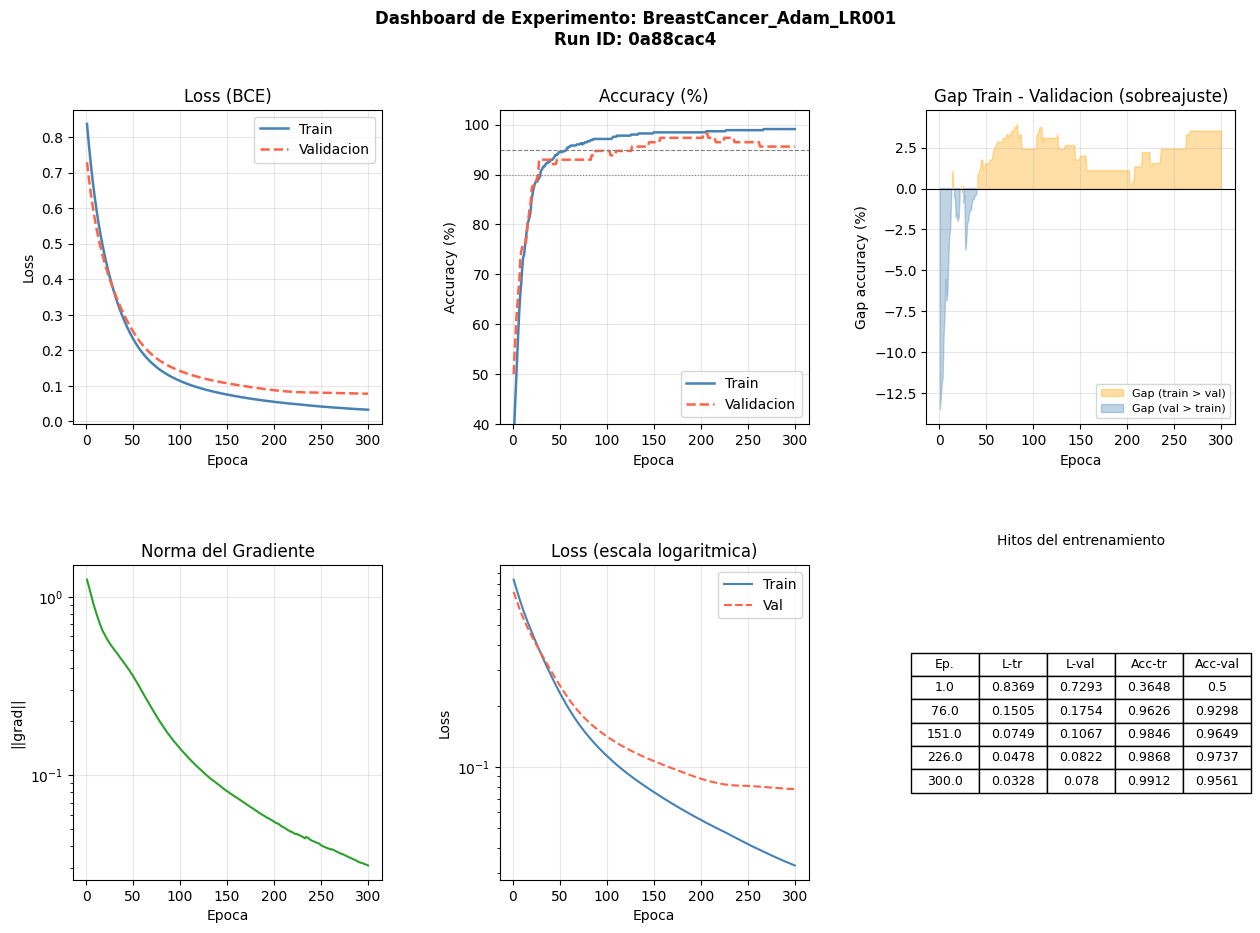

  Dashboard guardado como dashboard_experimento.png


In [10]:
# Dashboard grafico completo
logger.graficar()

In [11]:
# Exportar historial a JSON (trazabilidad)
logger.guardar_json('historial_experimento.json')

# Verificar contenido del archivo
with open('historial_experimento.json', 'r') as f:
    payload = json.load(f)
print(f"  Run ID         : {payload['run_id']}")
print(f"  Nombre         : {payload['nombre']}")
print(f"  Epocas logueadas: {len(payload['historia'])}")
print(f"  Ultima entrada : {payload['historia'][-1]}")

  Historial guardado en: historial_experimento.json
  Run ID         : 0a88cac4
  Nombre         : BreastCancer_Adam_LR001
  Epocas logueadas: 300
  Ultima entrada : {'epoca': 300, 'tiempo_s': 0.65, 'loss_train': 0.032836, 'loss_val': 0.07799, 'acc_train': 0.991209, 'acc_val': 0.95614, 'grad_norma': 0.031141}


---
## 7. Analisis de Metricas

In [24]:
# --- 7.1 Evaluación de rendimiento final ---
# Obtenemos probabilidades y convertimos a clases binarias usando un umbral de 0.5
y_prob  = red.predecir(X_test).flatten()
y_pred  = (y_prob >= 0.5).astype(int)
y_true  = y_test.flatten().astype(int)

# Cálculo de métricas estándar de clasificación
cm      = confusion_matrix(y_true, y_pred)
auc     = roc_auc_score(y_true, y_prob)
reporte = classification_report(y_true, y_pred,
                                 target_names=['Maligno (0)', 'Benigno (1)'])

print("=" * 60)
print("  EVALUACION FINAL EN TEST")
print("=" * 60)
print(f"  Accuracy  : {acc(y_test, y_prob.reshape(-1,1))*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print("  Reporte de clasificación (Precision, Recall, F1):")
print(reporte)
print("  Matriz de confusión (Valores reales vs Predichos):")
print(f"  {'':15} Pred. Maligno  Pred. Benigno")
print(f"  {'Real Maligno':15} {cm[0,0]:>13}  {cm[0,1]:>13}")
print(f"  {'Real Benigno':15} {cm[1,0]:>13}  {cm[1,1]:>13}")

  EVALUACION FINAL EN TEST
  Accuracy  : 95.61%
  ROC-AUC   : 0.9967

  Reporte de clasificación (Precision, Recall, F1):
              precision    recall  f1-score   support

 Maligno (0)       0.91      0.98      0.94        42
 Benigno (1)       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

  Matriz de confusión (Valores reales vs Predichos):
                  Pred. Maligno  Pred. Benigno
  Real Maligno               41              1
  Real Benigno                4             68


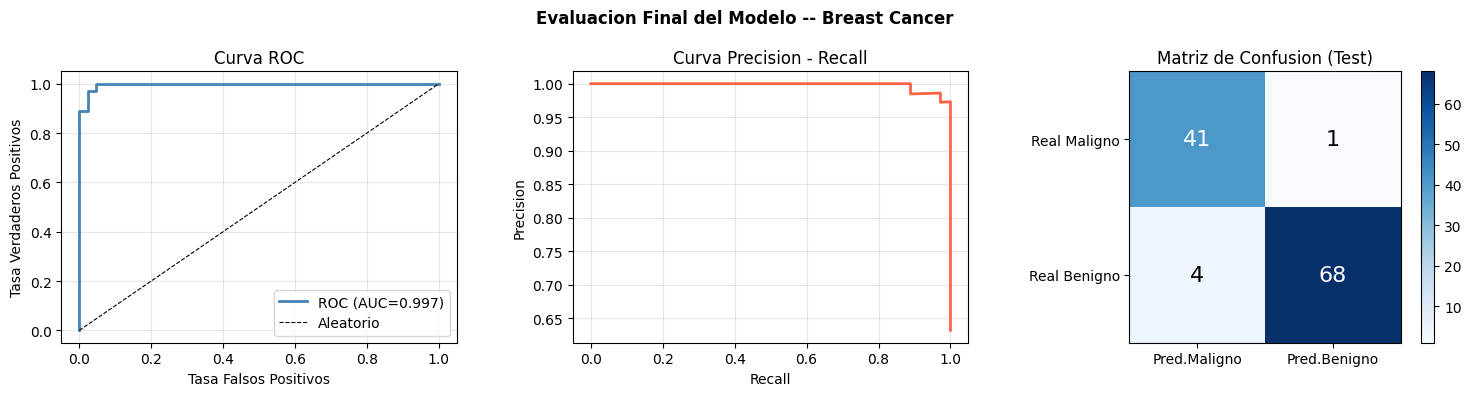

Graficas de evaluacion guardadas


In [13]:
# Graficas de evaluacion
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, _ = precision_recall_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Evaluacion Final del Modelo -- Breast Cancer', fontsize=12, fontweight='bold')

# Curva ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=0.8, label='Aleatorio')
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Curva Precision-Recall
axes[1].plot(rec, prec, color='tomato', lw=2)
axes[1].set_title('Curva Precision - Recall')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].grid(True, alpha=0.3)

# Matriz de confusion
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Pred.Maligno','Pred.Benigno'])
axes[2].set_yticklabels(['Real Maligno','Real Benigno'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[2].set_title('Matriz de Confusion (Test)')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('evaluacion_modelo.png', dpi=110, bbox_inches='tight')
plt.show()
print("Graficas de evaluacion guardadas")

---
## 8. Model Serving: Estrategias de Despliegue

### 8.1 Descripcion de opciones de despliegue

Un modelo entrenado no termina su ciclo de vida en la evaluacion. Para que genere valor, debe poder recibir nuevas entradas y producir predicciones en un entorno de produccion. Las principales alternativas son:

**Opcion A: API REST con FastAPI o Flask**
```
Cliente (JSON) --> POST /predict --> [Preprocesamiento] --> [Modelo] --> JSON con prediccion
```
Ventaja: sencillo, portable. Desventaja: requiere servidor activo.

**Opcion B: Contenedor Docker**
```
[Modelo + dependencias] --> Imagen Docker --> Cualquier plataforma cloud (AWS, GCP, Azure)
```
Ventaja: reproducible y escalable. Desventaja: mayor curva de aprendizaje.

**Opcion C: Serverless (AWS Lambda / GCP Cloud Functions)**
```
Evento --> [Funcion sin servidor] --> Prediccion --> Respuesta
```
Ventaja: pago por uso, sin administrar servidores. Desventaja: limitaciones de memoria y tiempo.

**Opcion D: Plataforma de inferencia (Hugging Face Spaces, Streamlit Cloud)**
Ideal para prototipos rapidos y demos interactivas sin infraestructura propia.

### 8.2 Estrategia recomendada para este modelo

Para el modelo de clasificacion de cancer de mama, la estrategia recomendada es una **API REST con FastAPI**, ya que:

- El modelo es pequeno (pesos en memoria, sin dependencias de GPU).
- Las predicciones son individuales (una muestra a la vez).
- FastAPI genera documentacion automatica (Swagger UI) que facilita la integracion con sistemas medicos.

A continuacion se muestra la **simulacion local de inferencia** y el esquema del endpoint.

In [22]:
# --- 8.3 Simulación de inferencia (Model Serving local) ---

def serializar_modelo(red, scaler):
    """
    Simula la exportación del modelo y el scaler a un formato portable.
    """
    return {
        'pesos':         {k: v.tolist() for k, v in red.p.items()},
        'scaler_mean':   scaler.mean_.tolist(),
        'scaler_scale':  scaler.scale_.tolist(),
        'arquitectura':  '30->32->16->1',
        'version':       '1.0.0',
    }

def endpoint_predict(artefacto, datos_crudos_json):
    """
    Simula un endpoint de API. Recibe datos crudos, aplica el
    preprocesamiento guardado y retorna la predicción.
    """
    # Carga de parámetros del scaler y red
    media, escala = np.array(artefacto['scaler_mean']), np.array(artefacto['scaler_scale'])
    red_srv = RedClasificacion(n_entrada=30)
    for k, v in artefacto['pesos'].items(): red_srv.p[k] = np.array(v)

    # Inferencia
    x = (np.array(datos_crudos_json['caracteristicas']) - media) / escala
    prob = float(red_srv.predecir(x.reshape(1, -1))[0,0])

    return {
        'diagnostico': 'Benigno' if prob >= 0.5 else 'Maligno',
        'confianza': round(max(prob, 1-prob) * 100, 2)
    }

# Ejecución de la prueba de Serving
artefacto_modelo = serializar_modelo(red, scaler)
print("Simulación de Serving lista.")

Simulación de Serving lista.


In [15]:
# --- 8.4 Esquema del endpoint FastAPI (codigo de referencia) ---
print("Esquema de implementacion FastAPI para este modelo:")
print("""
# archivo: main.py
# Ejecutar con: uvicorn main:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np, json

app = FastAPI(title='Clasificador Cancer de Mama', version='1.0.0')

class MuestraSchema(BaseModel):
    caracteristicas: list[float]   # 30 valores numericos

@app.get('/health')
def health():
    return {'estado': 'activo'}

@app.post('/predict')
def predict(entrada: MuestraSchema):
    # 1. Cargar artefacto del modelo (archivo JSON o pickle)
    # 2. Preprocesar entrada (normalizar con scaler del entrenamiento)
    # 3. Correr forward pass de la red
    # 4. Retornar probabilidad y clase
    respuesta = endpoint_predict(artefacto_modelo,
                                  {'caracteristicas': entrada.caracteristicas})
    return respuesta

# Documentacion automatica disponible en: http://localhost:8000/docs
""")

Esquema de implementacion FastAPI para este modelo:

# archivo: main.py
# Ejecutar con: uvicorn main:app --host 0.0.0.0 --port 8000

from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np, json

app = FastAPI(title='Clasificador Cancer de Mama', version='1.0.0')

class MuestraSchema(BaseModel):
    caracteristicas: list[float]   # 30 valores numericos

@app.get('/health')
def health():
    return {'estado': 'activo'}

@app.post('/predict')
def predict(entrada: MuestraSchema):
    # 1. Cargar artefacto del modelo (archivo JSON o pickle)
    # 2. Preprocesar entrada (normalizar con scaler del entrenamiento)
    # 3. Correr forward pass de la red
    # 4. Retornar probabilidad y clase
    respuesta = endpoint_predict(artefacto_modelo,
                                  {'caracteristicas': entrada.caracteristicas})
    return respuesta

# Documentacion automatica disponible en: http://localhost:8000/docs



---
## 9. Integracion con Weights and Biases (bloque listo para activar)

El siguiente bloque muestra como integrar el entrenamiento con la plataforma oficial de W&B. Para activarlo:
1. Crear una cuenta gratuita en [https://wandb.ai](https://wandb.ai).
2. Ejecutar `wandb login` en la terminal de Colab y pegar el API key.
3. Descomentar el bloque a continuacion y ejecutarlo.

In [16]:
# ============================================================
# INTEGRACION CON WEIGHTS AND BIASES
# Descomentar y ejecutar para activar el logging en W&B
# ============================================================

# !pip install wandb -q
# import wandb

# wandb.init(
#     project = 'breast-cancer-clasificacion',
#     name    = 'Adam-LR001-300ep',
#     config  = CONFIG
# )

# red_wandb = RedClasificacion(n_entrada=30, semilla=SEMILLA, lr=CONFIG['lr'])

# for ep in range(1, EPOCAS + 1):
#     y_hat_tr  = red_wandb.forward(X_train)
#     loss_tr   = bce(y_train, y_hat_tr)
#     acc_tr    = acc(y_train, y_hat_tr)
#     grads     = red_wandb.backward(y_train)
#     grad_norma = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
#     red_wandb.actualizar(grads)
#     y_hat_val = red_wandb.predecir(X_test)
#     loss_val  = bce(y_test, y_hat_val)
#     acc_val   = acc(y_test, y_hat_val)

#     wandb.log({
#         'epoca':      ep,
#         'loss_train': loss_tr,
#         'loss_val':   loss_val,
#         'acc_train':  acc_tr,
#         'acc_val':    acc_val,
#         'grad_norma': grad_norma,
#     })

# wandb.finish()
# print('Experimento registrado en W&B. Ver en: https://wandb.ai')

print("Bloque W&B listo para activar (instrucciones en la celda Markdown anterior)")

Bloque W&B listo para activar (instrucciones en la celda Markdown anterior)


---
## 10. Conclusiones Tecnicas

### 10.1 Data Journey

El recorrido de los datos evidencia que la preparacion consume una parte significativa del esfuerzo total. El dataset Breast Cancer Wisconsin es un caso ideal: ya se encuentra curado, sin valores nulos y en formato tabular. En escenarios reales, este paso incluye limpieza de outliers, imputacion de datos faltantes, codificacion de variables categoricas y posiblemente aumento de datos. La normalizacion con StandardScaler ajustado exclusivamente sobre el conjunto de entrenamiento es una practica critica: aplicar el scaler tambien sobre los datos de test antes de ajustarlo introducira fuga de informacion (data leakage) y resultados artificialmente optimistas.

### 10.2 Monitoreo y logging

El sistema de logging implementado registra seis metricas por epoca: loss de entrenamiento, loss de validacion, accuracy de entrenamiento, accuracy de validacion, norma del gradiente y tiempo transcurrido. El grafico de gap entre accuracy de entrenamiento y validacion es especialmente util: un gap creciente indica sobreajuste, mientras que un gap negativo sostenido puede indicar que el conjunto de test es mas facil que el de entrenamiento o que hay un problema de balanceo. La norma del gradiente en escala logaritmica permite detectar tempranamente si los gradientes se estan desvaneciendo o explotando, lo que guia la seleccion de hiperparametros.

### 10.3 Metricas de evaluacion

El accuracy no es suficiente para problemas medicos. En diagnostico de cancer, los falsos negativos (predecir benigno cuando es maligno) tienen consecuencias mucho mas graves que los falsos positivos. Por esto, el **recall de la clase maligna** y el **ROC-AUC** son las metricas prioritarias. Un AUC cercano a 1.0 indica que el modelo puede discriminar correctamente entre clases a cualquier umbral de decision, lo que permite ajustar el umbral (por ejemplo a 0.3 en lugar de 0.5) para reducir los falsos negativos a costa de aumentar los falsos positivos, segun la necesidad clinica.

### 10.4 Model Serving

La simulacion del endpoint evidencia que el ciclo de vida del modelo no termina en la evaluacion. El preprocesamiento (normalizacion) debe encapsularse junto con el modelo para garantizar que los datos de produccion reciban exactamente el mismo tratamiento que los de entrenamiento. El artefacto serializado incluye tanto los pesos de la red como los parametros del scaler. En produccion, el versionado del artefacto y la trazabilidad del run ID permiten reproducir exactamente el comportamiento de cualquier prediccion pasada.

### 10.5 Dificultades y oportunidades de mejora

**Dificultades identificadas:**
- La implementacion manual de backpropagation requiere cuidado en el manejo de dimensiones de los tensores.
- La seleccion del umbral de clasificacion optimo es un proceso que en produccion deberia basarse en la curva ROC y en criterios clinicos, no en 0.5 por defecto.

**Oportunidades de mejora:**
- Implementar regularizacion (L2 o Dropout) para mejorar la generalizacion.
- Agregar early stopping basado en el loss de validacion para evitar sobreajuste.
- Usar validacion cruzada (k-fold) para una estimacion mas robusta del desempeno.
- Integrar W&B para persistencia remota del historial y comparacion entre corridas.
- Containerizar el endpoint con Docker para facilitar el despliegue reproducible.

In [26]:
# --- Resumen de finalización de ejecución ---
print("=" * 60)
print(" Notebook completado exitosamente")
print(" Semana 5 - Data Journey, Monitoreo y Model Serving")
print("=" * 60)

# Resumen de métricas finales para el log
df_f = pd.DataFrame(logger.historia)
print(f" Run ID           : {logger.run_id}")
print(f" Epocas           : {EPOCAS}")
print(f" Loss train final : {df_f['loss_train'].iloc[-1]:.6f}")
print(f" Loss val final   : {df_f['loss_val'].iloc[-1]:.6f}")
print(f" Acc val final    : {df_f['acc_val'].iloc[-1]*100:.2f}%")
print(f" ROC-AUC (test)   : {auc:.4f}")
print(f" Tiempo total     : {tiempo_total}s")
print(f" Archivos generados para reporte:")
print(f"   - dashboard_experimento.png")
print(f"   - evaluacion_modelo.png")
print(f"   - historial_experimento.json")
print("=" * 60)

 Notebook completado exitosamente
 Semana 5 - Data Journey, Monitoreo y Model Serving
 Run ID           : 874a0fa0
 Epocas           : 300
 Loss train final : 0.032836
 Loss val final   : 0.077990
 Acc val final    : 95.61%
 ROC-AUC (test)   : 0.9967
 Tiempo total     : 0.64s
 Archivos generados para reporte:
   - dashboard_experimento.png
   - evaluacion_modelo.png
   - historial_experimento.json
